# Regression Practice 

For gaining familiarity with using Python for regression problems instead of relying on R.

## SETUP

In [1]:
import typing as T

import datasets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn.impute as skimp
import sklearn.preprocessing as skprep
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

/Users/keifer/Desktop/projects/datalab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## DATA COLLECTION

In [2]:
ds = datasets.load_dataset("michaelmallari/house-prices-advanced-regression-techniques")
train_src_df = ds["train"].to_pandas()
test_src_df = ds["test"].to_pandas()

## EDA

In [3]:
train_src_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
train_src_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Gap Analysis

In [5]:
cols_with_nulls = train_src_df.isnull().sum().loc[lambda x: x > 0]
cols_with_nulls

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [6]:
cols_to_drop = cols_with_nulls.loc[
    lambda x: x > train_src_df.shape[0] / 4
].index.to_list()
cols_to_drop

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

### Encoding Analysis

In [7]:
def list_unique(df: pd.DataFrame | T.Iterator[pd.DataFrame], col: str) -> list[str]:
    return df.loc[:, col].unique().dropna().tolist()

In [8]:
encodable_cols = (
    train_src_df.loc[:, ~train_src_df.columns.isin(cols_to_drop)]
    .select_dtypes(["object", "str"])
    .nunique(dropna=True)
    .index
)
for col in encodable_cols:
    print(f"{col}: {list_unique(train_src_df, col)}")

MSZoning: ['RL', 'RM', 'C (all)', 'FV', 'RH']
Street: ['Pave', 'Grvl']
LotShape: ['Reg', 'IR1', 'IR2', 'IR3']
LandContour: ['Lvl', 'Bnk', 'Low', 'HLS']
Utilities: ['AllPub', 'NoSeWa']
LotConfig: ['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
LandSlope: ['Gtl', 'Mod', 'Sev']
Neighborhood: ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst', 'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes', 'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU', 'Blueste']
Condition1: ['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Condition2: ['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe']
BldgType: ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
HouseStyle: ['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf', '2.5Fin']
RoofStyle: ['Gable', 'Hip', 'Gambrel', 'Mansard', 'Flat', 'Shed']
RoofMatl: ['CompShg', 'WdShngl', 'Metal', 'WdShake', 'Membran'

### Distribution Analysis

In [9]:
def plot_eda_kdes(df: pd.DataFrame | T.Iterator[pd.DataFrame]):
    numerical_features = df.select_dtypes(include=["number"]).columns
    num_features = len(numerical_features)
    if num_features % 2 != 0:
        num_features += 1

    plt.figure(figsize=(15, num_features * 3))
    for idx, feature in enumerate(numerical_features, 1):
        plt.subplot(num_features, 2, idx)
        sns.histplot(df[feature], kde=True)
        plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

    plt.tight_layout()
    plt.show()

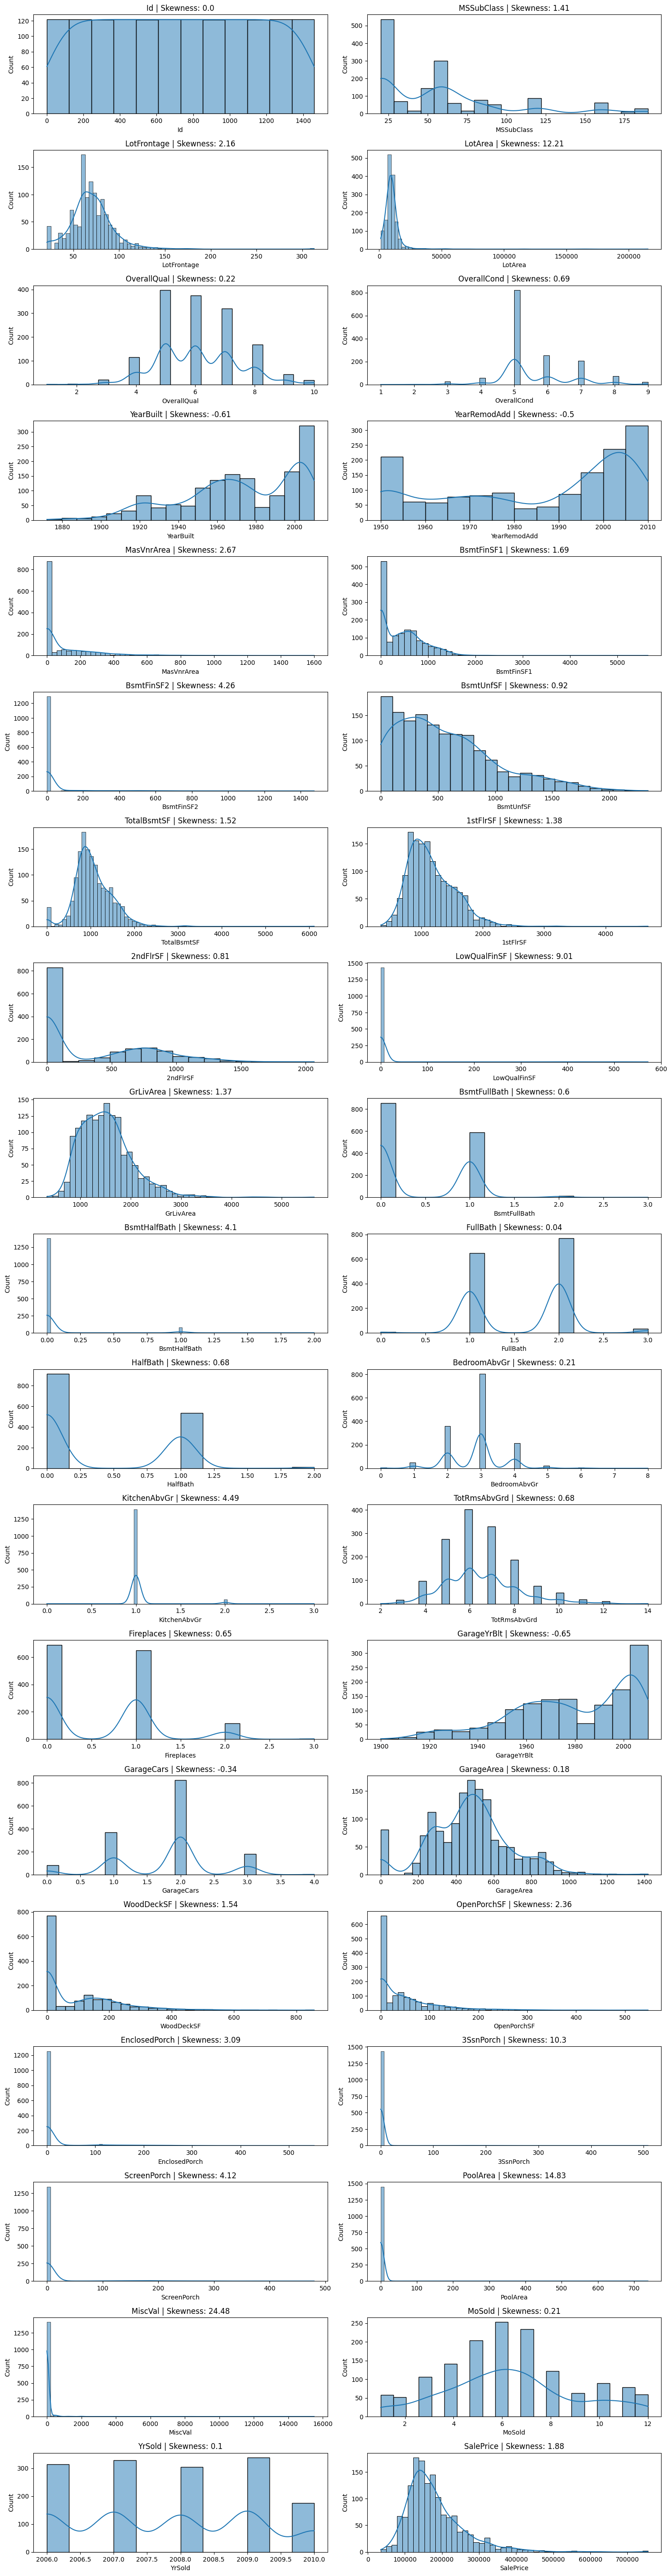

In [10]:
plot_eda_kdes(train_src_df)

## DATA PREPROCESSING

In [11]:
def plot_corr_matrix(df: pd.DataFrame | T.Iterator[pd.DataFrame]):
    plt.figure(figsize=(20, 25))
    sns.heatmap(train_prep_df.corr())
    plt.show()

In [12]:
train_prep_df = train_src_df.loc[
    :, ~train_src_df.columns.isin(cols_to_drop + ["Id"] + ["SalePrice"])
]
train_prep_df = pd.get_dummies(
    train_prep_df, columns=encodable_cols, drop_first=True, dtype="int"
)
train_prep_df = (
    skimp.SimpleImputer(missing_values=pd.NA, strategy="most_frequent")
    .set_output(transform="pandas")
    .fit_transform(train_prep_df)
)
train_prep_df = (
    skprep.StandardScaler().set_output(transform="pandas").fit_transform(train_prep_df)
)

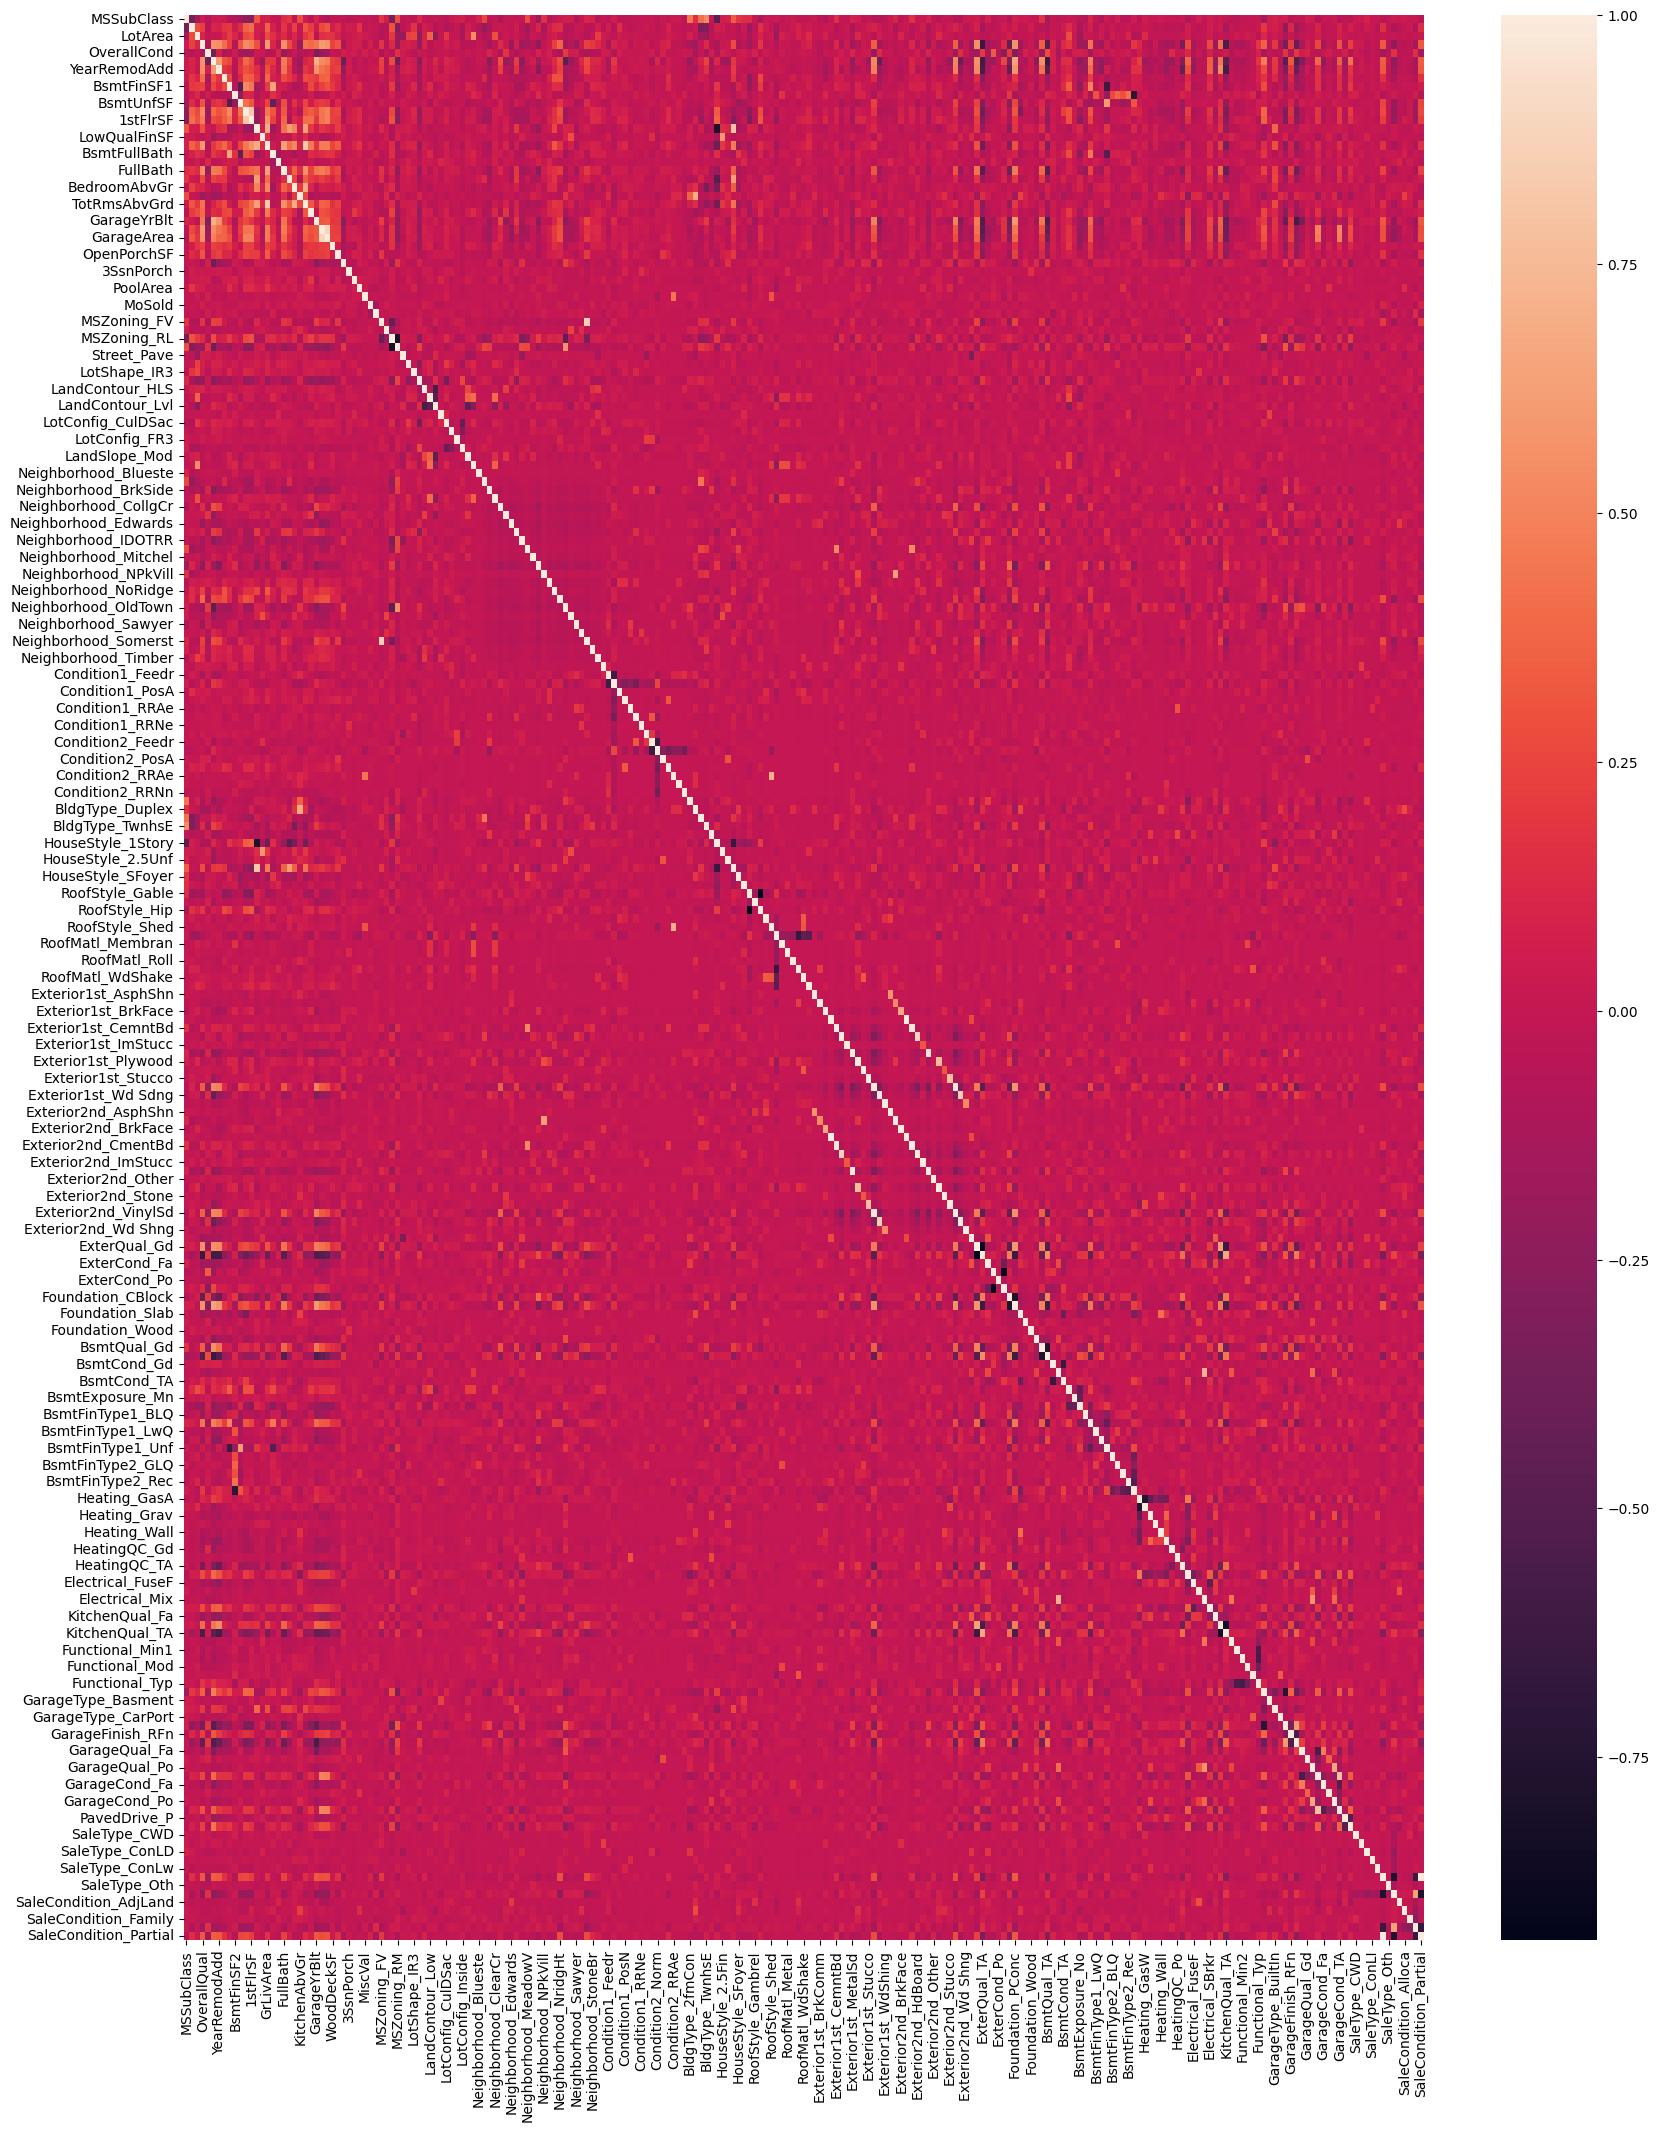

In [13]:
plot_corr_matrix(train_prep_df)

In [14]:
def calc_vif(
    src_df: pd.DataFrame, vif_to_drop: list[str] = []
) -> tuple[pd.DataFrame, list[str]]:
    df = src_df.copy()
    df = sm.add_constant(df)  # for intercept

    vif_df = pd.DataFrame()
    vif_df.loc[:, "variable"] = df.columns
    vif_df.loc[:, "vif"] = [vif(df.values, i) for i in range(df.shape[1])]
    vif_df = vif_df.sort_values(by="vif", ascending=False).reset_index(drop=True)

    to_drop = vif_df.loc[vif_df["vif"] == float("inf")].loc[:, "variable"].to_list()

    if vif_df.at[0, "vif"] > 3:
        to_drop += [vif_df.at[0, "variable"]]
        print(to_drop)

        return calc_vif(df.drop(to_drop + ["const"], axis=1), vif_to_drop + to_drop)

    return vif_df, vif_to_drop

In [15]:
vif_df, to_drop = calc_vif(train_prep_df)
vif_df

/Users/keifer/Desktop/projects/datalab/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


['2ndFlrSF', 'BsmtFinSF1', 'Exterior2nd_CBlock', 'GrLivArea', 'LowQualFinSF', '1stFlrSF', 'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF2', 'Exterior1st_CBlock', '2ndFlrSF']
['GarageCond_TA']
['RoofStyle_Gable']
['Exterior1st_VinylSd']
['ExterCond_TA']
['GarageType_Attchd']
['SaleType_New']
['MSZoning_RL']
['Exterior2nd_MetalSd']
['RoofMatl_CompShg']
['Heating_GasA']
['MSSubClass']
['Exterior2nd_CmentBd']
['Neighborhood_NAmes']
['Exterior2nd_VinylSd']
['ExterQual_TA']
['YearBuilt']
['Exterior1st_HdBoard']
['Condition2_Norm']
['KitchenQual_TA']
['Functional_Typ']
['BsmtQual_TA']
['Exterior2nd_Wd Sdng']
['BsmtFinType2_Unf']
['GarageCars']
['Foundation_PConc']
['GarageQual_TA']
['Neighborhood_Somerst']
['HouseStyle_1Story']
['SaleType_WD']
['Condition1_Norm']
['TotRmsAbvGrd']
['OverallQual']
['Neighborhood_OldTown']
['GarageYrBlt']
['KitchenAbvGr']
['Electrical_Mix']
['Exterior2nd_Brk Cmn']
['Exterior2nd_Stucco']
['BsmtFinType1_Unf']
['Exterior1st_Plywood']
['BsmtCond_TA']
['RoofStyle_Shed']
['La

,variable,vif
0,Foundation_CBlock,2.951195
1,YearRemodAdd,2.922598
2,SaleCondition_Partial,2.905348
3,SaleCondition_Normal,2.890248
4,LotArea,2.805995
...,...,...
170,SaleType_Oth,1.108170
171,SaleType_CWD,1.103505
172,Exterior2nd_Other,1.084262
173,SaleType_ConLI,1.082079


In [16]:
train_prep_df = train_prep_df.drop(to_drop, axis=1)

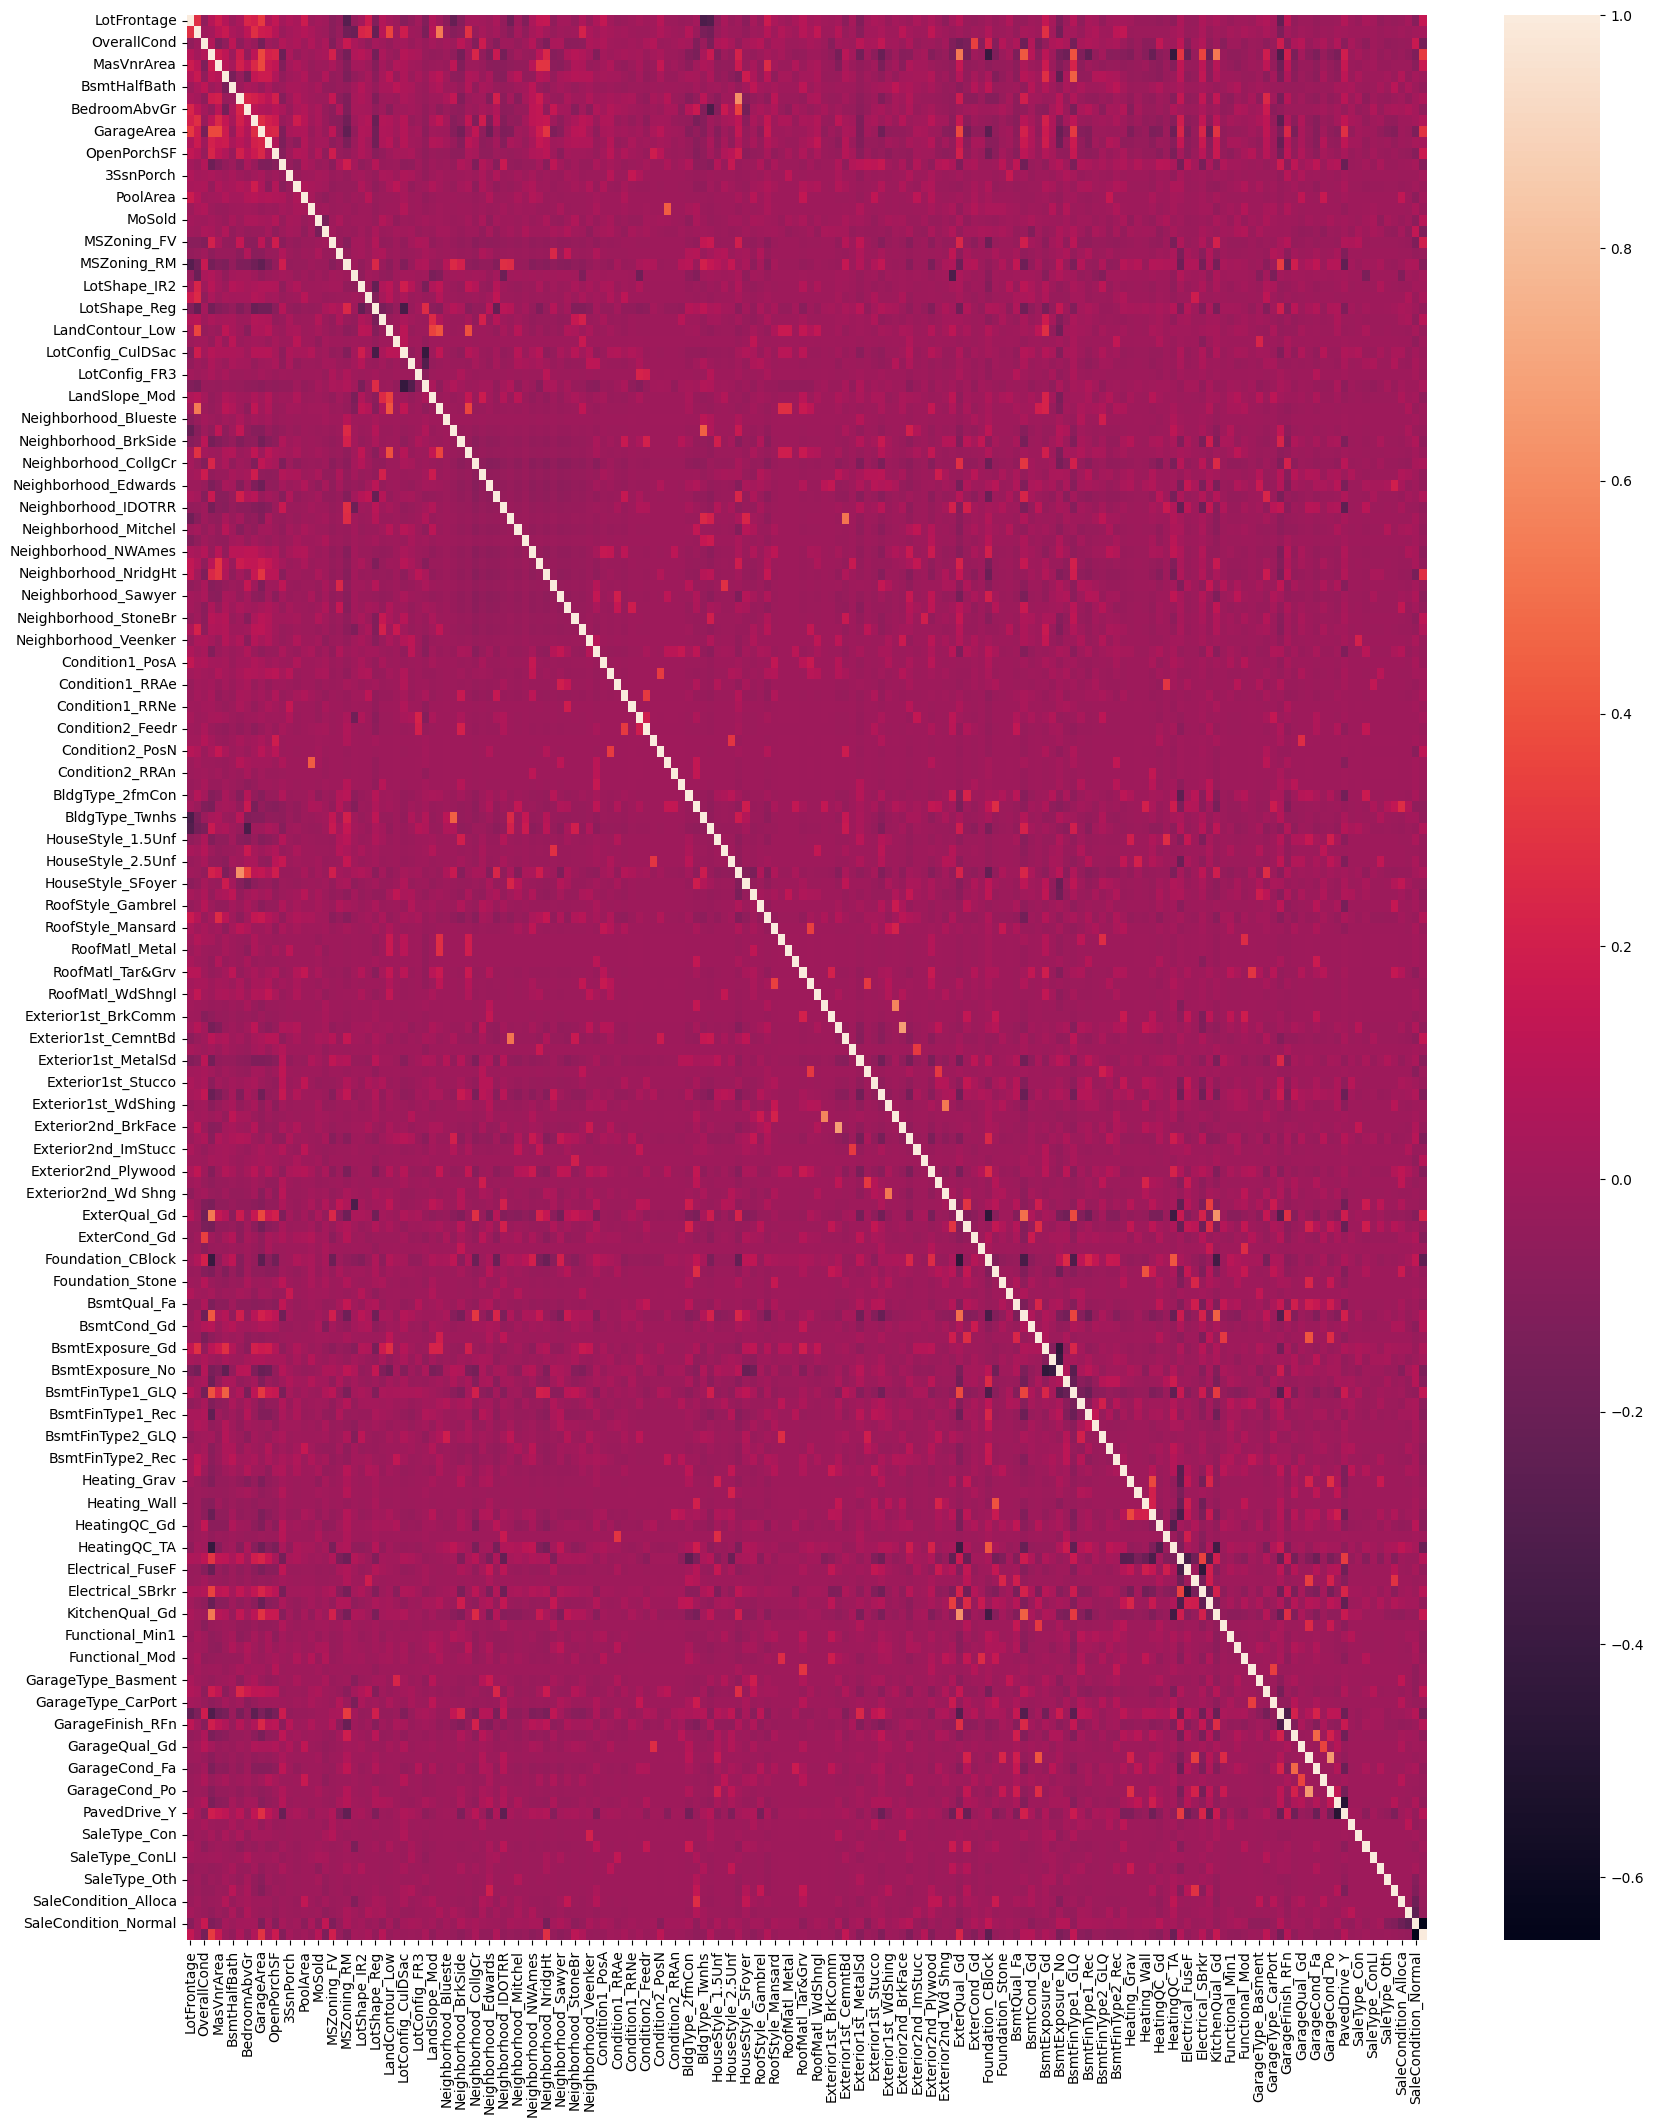

In [17]:
plot_corr_matrix(train_prep_df)

## REGRESSION

In [20]:
lm = sm.OLS(train_src_df["SalePrice"], sm.add_constant(train_prep_df)).fit()

In [21]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     39.49
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:36:31   Log-Likelihood:                -17195.
No. Observations:                1460   AIC:                         3.474e+04
Df Residuals:                    1285   BIC:                         3.567e+04
Df Model:                         174                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  1.809e+05    879.350    205.744      0.000    1.79e+05    1.83e+05
LotFrontage             833.2094   1290.281      0.646      0.519   -1698.080    3364.499
LotArea                8481.9139   1473.008      5.758      0.000    5592.149    1.14e+04
OverallCond            3266.9541   1257.394      2.598      0.009     800.183    5733.725
YearRemodAdd           9249.2938   1503.302      6.153      0.000    6300.099    1.22e+04
MasVnrArea             7153.6461   1180.117      6.062      0.000    4838.478    9468.814
BsmtFullBath           1955.5056   1186.359      1.648      0.100    -371.907    4282.918
BsmtHalfBath           -481.2871    999.319     -0.482      0.630   -2441.763    1479.189
HalfBath               3644.9526   1307.466      2.788      0.005    1079.950    6209.955
BedroomAbvGr           7756.9659   1269.227      6.112      0.000    5266.981    1.02e+04
Fireplaces             9520.1359   1165.952      8.165      0.000    7232.757    1.18e+04
GarageArea             1.392e+04   1344.490     10.356      0.000    1.13e+04    1.66e+04
WoodDeckSF             3843.1677   1051.470      3.655      0.000    1780.382    5905.954
OpenPorchSF            3066.8337   1059.214      2.895      0.004     988.855    5144.812
EnclosedPorch           296.8717   1055.806      0.281      0.779   -1774.422    2368.165
3SsnPorch              1512.0787    954.809      1.584      0.114    -361.076    3385.233
ScreenPorch            2876.6020    976.412      2.946      0.003     961.066    4792.138
PoolArea               3402.1480   1010.867      3.366      0.001    1419.017    5385.279
MiscVal                -191.1018   1025.641     -0.186      0.852   -2203.216    1821.012
MoSold                -1464.8550    946.216     -1.548      0.122   -3321.153     391.443
YrSold                 -644.4080    972.150     -0.663      0.508   -2551.583    1262.767
MSZoning_FV            5589.8527   1231.308      4.540      0.000    3174.258    8005.448
MSZoning_RH            -678.4746    996.101     -0.681      0.496   -2632.638    1275.689
MSZoning_RM           -1660.1139   1342.902     -1.236      0.217   -4294.635     974.407
Street_Pave            4576.7202   1068.444      4.284      0.000    2480.633    6672.807
LotShape_IR2            812.9539    999.383      0.813      0.416   -1147.647    2773.555
LotShape_IR3          -3004.0444   1024.198     -2.933      0.003   -5013.329    -994.760
LotShape_Reg           -111.1155   1106.158     -0.100      0.920   -2281.190    2058.959
LandContour_HLS         315.8472   1057.907      0.299      0.765   -1759.567    2391.262
LandContour_Low       -3300.3691   1228.706     -2.686      0.007   -5710.859    -889.880
Utilities_NoSeWa      -1376.6567    976.586     -1.410      0.159   -3292.534     539.221
LotConfig_CulDSac      